In [130]:
import numpy as np
import sympy as sp
from sympy.plotting import plot_implicit
import matplotlib.pyplot as plt

## A

In [133]:
y = np.array([0.39, 0.32, 0.27, 0.22, 0.18, 0.15, 0.13, 0.12, 0.13, 0.15])
y_2 = y**2
x = np.array([1.02, 0.95, 0.87, 0.77, 0.67, 0.56, 0.44, 0.30, 0.16, 0.01])
xy = x*y
l = np.ones((10))
A_T = np.vstack((y_2, xy, x, y, l))

In [135]:
A = A_T.T
A

array([[0.1521, 0.3978, 1.02  , 0.39  , 1.    ],
       [0.1024, 0.304 , 0.95  , 0.32  , 1.    ],
       [0.0729, 0.2349, 0.87  , 0.27  , 1.    ],
       [0.0484, 0.1694, 0.77  , 0.22  , 1.    ],
       [0.0324, 0.1206, 0.67  , 0.18  , 1.    ],
       [0.0225, 0.084 , 0.56  , 0.15  , 1.    ],
       [0.0169, 0.0572, 0.44  , 0.13  , 1.    ],
       [0.0144, 0.036 , 0.3   , 0.12  , 1.    ],
       [0.0169, 0.0208, 0.16  , 0.13  , 1.    ],
       [0.0225, 0.0015, 0.01  , 0.15  , 1.    ]])

In [137]:
w = x**2
w

array([1.0404, 0.9025, 0.7569, 0.5929, 0.4489, 0.3136, 0.1936, 0.09  ,
       0.0256, 0.0001])

In [139]:
z, residuals, rank, s = np.linalg.lstsq(A, w, rcond=None)
z

array([-2.6356,  0.1436,  0.5514,  3.2229, -0.4329])

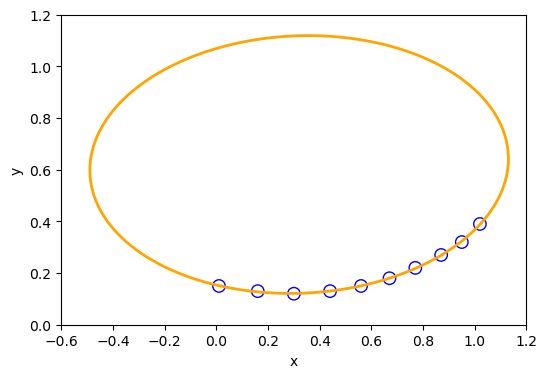

In [141]:
# x_vals = x
# y_vals = y

# Your result for z should be a numpy array: z = [a, b, c, d, e]
a, b, c, d, e = [float(val) for val in z]

# Generate grid
xx = np.linspace(-0.6, 1.2, 600)
yy = np.linspace(0, 1.2, 600)
XX, YY = np.meshgrid(xx, yy)

# Quadratic equation for ellipse over grid
F = a*YY**2 + b*XX*YY + c*XX + d*YY + e - XX**2

plt.figure(figsize=(6,6))
plt.contour(XX, YY, F, levels=[0], colors='orange', linewidths=2)  # Ellipse plot
plt.scatter(x, y, facecolors='none', edgecolors='blue', s=80)  # Open circles
plt.xlim(-0.6, 1.2)
plt.ylim(0, 1.2)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


## B

In [144]:
rng = np.random.default_rng(42)
x_pert = x + rng.uniform(-0.005, 0.005, size=len(x))
y_pert = y + rng.uniform(-0.005, 0.005, size=len(y))

In [146]:
A_pert = np.column_stack([
    y_pert**2,
    x_pert * y_pert,
    x_pert,
    y_pert,
    np.ones_like(x_pert)
])

w_pert = x_pert**2

In [150]:
z_pert, residuals_pert, rank_pert, s_pert = np.linalg.lstsq(A_pert, w_pert, rcond=None)
np.linalg.norm(z - z_pert)

1.2175934180635601

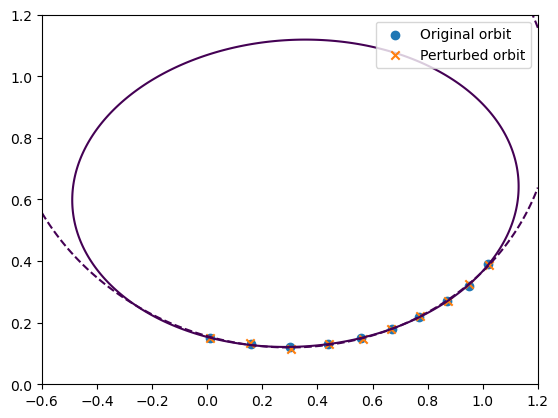

In [152]:
def f_conic(z, X, Y):
    a, b, c, d, e = z
    return a*(Y**2) + b*(X*Y) + c*X + d*Y + e - X**2

plt.contour(XX, YY, f_conic(z, XX, YY), levels=[0])             # original
plt.contour(XX, YY, f_conic(z_pert, XX, YY), levels=[0], 
            linestyles='--')                                   # perturbed
plt.scatter(x, y)
plt.scatter(x_pert, y_pert, marker='x')
plt.legend(["Original orbit", "Perturbed orbit", 
            "Original data", "Perturbed data"])

The orbit deviates greatly more so in the top rather than the lower half. This could be because there is no data regarding the top of the original orbit or looking based on the singular values of matrix A, we can see one of the singular values as very small so this could mean the matrix is ill conditioned.

## C

Singular values (decreasing):
[3.786  0.9449 0.2089 0.023  0.0055]

Full SVD solution z (a,b,c,d,e):
[-2.6356  0.1436  0.5514  3.2229 -0.4329]

SVD truncated k=1 solution:
[0.019  0.0547 0.2117 0.0737 0.3361]

SVD truncated k=2 solution:
[ 0.1044  0.3401  0.8918  0.2025 -0.1718]

SVD truncated k=3 solution:
[ 0.4192  0.8769  0.5253  0.7561 -0.1674]

SVD truncated k=4 solution:
[-0.6528 -0.9451  0.7168  3.261  -0.48  ]

SVD truncated k=5 solution:
[-2.6356  0.1436  0.5514  3.2229 -0.4329]


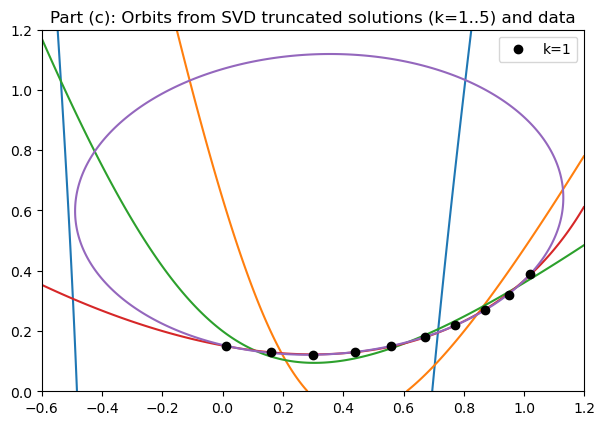

In [157]:
# Compute SVD
U, s_vals, Vt = np.linalg.svd(A, full_matrices=False)
V = Vt.T

print("Singular values (decreasing):")
print(s_vals)

# Full SVD (minimum-norm least squares solution)
z_svd_full = V @ ((U.T @ w) / s_vals)
print("\nFull SVD solution z (a,b,c,d,e):")
print(z_svd_full)

# Truncated SVD solutions
svd_solutions = []
for k in range(1,6):
    coeffs = np.array([ (U[:,i].T @ w) / s_vals[i] for i in range(k) ])
    z_k = V[:, :k] @ coeffs
    svd_solutions.append(z_k)
    print(f"\nSVD truncated k={k} solution:")
    print(z_k)

# Plotting (implicit contour for each z_k)
xx = np.linspace(-0.6, 1.2, 600)
yy = np.linspace(0, 1.2, 600)
XX, YY = np.meshgrid(xx, yy)

def f_conic_z(z, X, Y):
    a,b,c,d,e = z
    return a*(Y**2) + b*(X*Y) + c*X + d*Y + e - X**2

plt.figure(figsize=(7,7))
colors = ['C0','C1','C2','C3','C4']
for k,z_k in enumerate(svd_solutions, start=1):
    plt.contour(XX, YY, f_conic_z(z_k, XX, YY), levels=[0], colors=colors[k-1])

plt.scatter(x, y, color='black', zorder=3, label='data points')
plt.xlim(-0.6, 1.2); plt.ylim(0, 1.2)
plt.gca().set_aspect('equal', 'box')
plt.title("Part (c): Orbits from SVD truncated solutions (k=1..5) and data")
plt.legend([f'k={i}' for i in range(1,6)] + ['data points'])
plt.show()


## D

In [118]:
orig_solutions = []
for k in range(1,6):
    coeffs = np.array([(U[:,i].T @ w) / s_vals[i] for i in range(k)])
    z_k = V[:, :k] @ coeffs
    orig_solutions.append(z_k)
z_full = V @ ((U.T @ w) / s_vals)


U_p, s_p, Vt_p = np.linalg.svd(A_pert, full_matrices=False)
V_p = Vt_p.T
pert_solutions = []
for k in range(1,6):
    coeffs_p = np.array([(U_p[:,i].T @ w_pert) / s_p[i] for i in range(k)])
    z_kp = V_p[:, :k] @ coeffs_p
    pert_solutions.append(z_kp)
z_full_pert = V_p @ ((U_p.T @ w_pert) / s_p)
diffs = [np.linalg.norm(orig_solutions[i] - pert_solutions[i]) for i in range(5)]
diff_full = np.linalg.norm(z_full - z_full_pert)

In [120]:
np.set_printoptions(precision=4, suppress=True)
print("Original singular values:", s_vals)
print("Perturbed singular values:", s_p)
print("\nOriginal full SVD solution z_full:\n", z_full)
print("\nPerturbed full SVD solution z_full_pert:\n", z_full_pert)
print("\nNorm difference full solution:", diff_full)
for k in range(1,6):
    print(f"\nk={k} original z_k:\n", orig_solutions[k-1])
    print(f"k={k} perturbed z_k:\n", pert_solutions[k-1])
    print(f"Norm difference (k={k}): {diffs[k-1]:.6e}")

Original singular values: [3.786  0.9449 0.2089 0.023  0.0055]
Perturbed singular values: [3.7885 0.9473 0.2107 0.0246 0.0051]

Original full SVD solution z_full:
 [-2.6356  0.1436  0.5514  3.2229 -0.4329]

Perturbed full SVD solution z_full_pert:
 [-1.5125 -0.0822  0.6046  2.815  -0.4033]

Norm difference full solution: 1.2175934180635817

k=1 original z_k:
 [0.019  0.0547 0.2117 0.0737 0.3361]
k=1 perturbed z_k:
 [0.0191 0.0552 0.2127 0.0741 0.337 ]
Norm difference (k=1): 1.487290e-03

k=2 original z_k:
 [ 0.1044  0.3401  0.8918  0.2025 -0.1718]
k=2 perturbed z_k:
 [ 0.1047  0.3414  0.8913  0.2028 -0.1713]
Norm difference (k=2): 1.517936e-03

k=3 original z_k:
 [ 0.4192  0.8769  0.5253  0.7561 -0.1674]
k=3 perturbed z_k:
 [ 0.4193  0.8783  0.5211  0.7668 -0.1674]
Norm difference (k=3): 1.157410e-02

k=4 original z_k:
 [-0.6528 -0.9451  0.7168  3.261  -0.48  ]
k=4 perturbed z_k:
 [-0.4257 -0.6609  0.6933  2.8181 -0.427 ]
Norm difference (k=4): 5.761582e-01

k=5 original z_k:
 [-2.6356

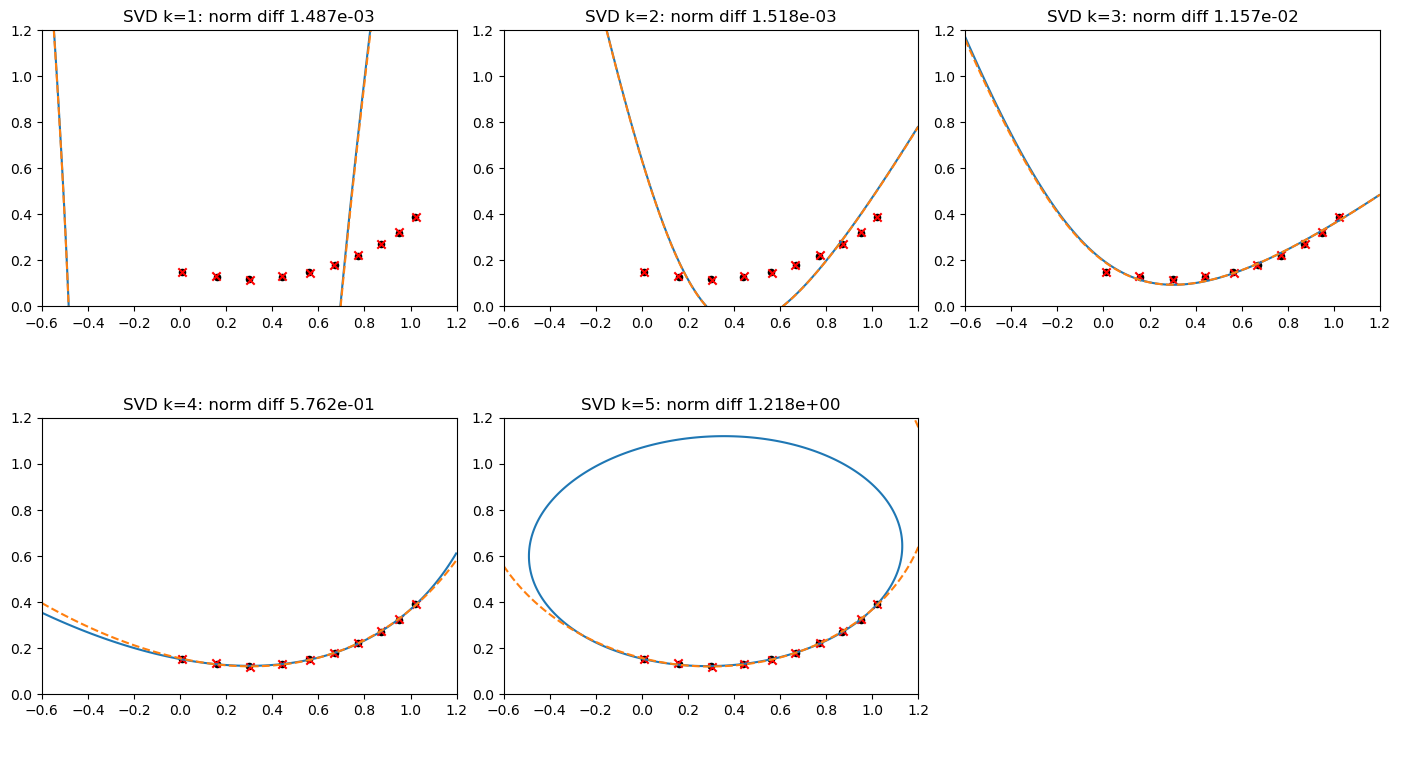

In [122]:
# Plot comparison
xx = np.linspace(-0.6, 1.2, 600)
yy = np.linspace(0, 1.2, 600)
XX, YY = np.meshgrid(xx, yy)
def fz(z, X, Y):
    a,b,c,d,e = z
    return a*(Y**2) + b*(X*Y) + c*X + d*Y + e - X**2

fig, axes = plt.subplots(2,3, figsize=(14,8))
axes = axes.ravel()
for i in range(5):
    ax = axes[i]
    z_o = orig_solutions[i]
    z_p = pert_solutions[i]
    ax.contour(XX, YY, fz(z_o, XX, YY), levels=[0], colors='C0')
    ax.contour(XX, YY, fz(z_p, XX, YY), levels=[0], colors='C1', linestyles='--')
    ax.scatter(x, y, color='black', s=20)
    ax.scatter(x_pert, y_pert, color='red', marker='x')
    ax.set_title(f"SVD k={i+1}: norm diff {diffs[i]:.3e}")
    ax.set_xlim(-0.6,1.2); ax.set_ylim(0,1.2)
    ax.set_aspect('equal', 'box')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

The different plost showcase the how the pattern of the orbit differs based on the number of sigular values used. We can see as we use more singular values, the orbits begin to match up less and difference is more noticeable. This indicates to me that that one that is less sensitive to perturbations in the data is better as it is more accurate. 